# Ploting Body acceleration (BA) data during locomotor transition

by Debora Masini, 2025

This scripts creates a peri-transition average of an IMU signal (“filtered_BA”) around locomotor-state transitions defined by the binary “movements” column, then saves a summary CSV + a plot.
Outputs:
 - peri_transition_filtered_ba.png: Plot with 95% CI shading.
 - peri_transition_filtered_ba_summary.csv: Summary statistics.

### Overview of Workflow

1) Load + restrict data
Reads Final_IMU body movement data sets.csv. Verifies required columns exist: IMU Time (s), filtered_BA, movements. Keeps only Day1 rows.

2) Estimate sampling rate from timestamps (intead of relying on the inscopix 50Hz report)
Computes diff = np.diff(IMU Time (s)) (positive only). Uses median dt to estimate sample rate: fs = 1 / median(dt).

3) Clean the movement state labels (debounce). Is assumed to be 0 = still, 1 = moving. fill_short_runs(mov, min_run_frames) removes short “blips” shorter than MIN_RUN_SEC by flipping them only if the states on both sides match.

4) Find clean transitions and extract windows of IMU signal. For each group (by Animal ID and Day; but I already filtered to Day1, so practically per animal):
    a) Move → Still transitions. Keep only “clean” transitions.
    b) Still → Move transitions. Keep only “clean” transitions.
    c) Still reference windows. Finds timepoints that sit inside long enough still periods (length 2*window_frames).

5) Aggregate across all mice + compute mean ± 95% CI...For each condition: Stacks windows into a matrix (n_windows × n_timepoints). Computes: mean across windows and 95% CI 

6) Save outputs
Vertical dashed line at t=0 (the transition time)

In [ ]:
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:

# What does filtered acceleration look like in the 1 s before vs 1 s after a movement transition?” averaged over many transitions, with a immobile-only group added for comparison.

# Params
IMU_FILE = r"...\python_analysis_results\Final_IMU body movement data sets.csv"
WINDOW_SEC = 1.0  # half-window...Only transitions embedded inside ≥1 s stable states on both sides are accepted.
MIN_RUN_SEC = 0.03 # min run length...shortest biologically plausible bout duration.30ms. Anything shorter is treated as noise.
OUTPUT_DIR = r"..."


@dataclass
class TransitionWindows:
    move_to_still: List[np.ndarray]
    still_to_move: List[np.ndarray]
    still_reference: List[np.ndarray]
    sample_rate: float
    window_frames: int

# actually estimate IMU data recording rate instead of taking the company report for granted. expected 50Hz.
def estimate_sample_rate(times: np.ndarray) -> Optional[float]:
    if times.size < 2:
        return None
    diffs = np.diff(times)
    diffs = diffs[diffs > 0]
    if diffs.size == 0:
        return None
    return 1.0 / np.median(diffs)


def fill_short_runs(arr: np.ndarray, min_len: int) -> np.ndarray:
    arr = arr.copy()
    n = len(arr)
    i = 0
    while i < n:
        val = arr[i]
        j = i
        while j < n and arr[j] == val:
            j += 1
        run_len = j - i
        # Fill only if both neighbors are identical
        if run_len < min_len and i > 0 and j < n and arr[i - 1] == arr[j]:
            arr[i:j] = arr[i - 1]
        i = j
    return arr


def collect_windows(
    df: pd.DataFrame,
    sample_rate: float,
    window_sec: float,
    min_run_sec: float,
) -> TransitionWindows:

    window_frames = int(round(window_sec * sample_rate))
    ref_window_frames = 2 * window_frames
    min_run_frames = max(1, int(round(min_run_sec * sample_rate)))

    mov = df["movements"].to_numpy()
    mov = fill_short_runs(mov, min_run_frames) # Before transitions are detected, scans for run is shorter than min_run_frames AND if it is flanked by the same state on both sides, replaces the short run with the surrounding state
    ba = df["filtered_BA"].to_numpy() # filtered_BA

    transitions_m2s = np.where((mov[:-1] == 1) & (mov[1:] == 0))[0] + 1
    transitions_s2m = np.where((mov[:-1] == 0) & (mov[1:] == 1))[0] + 1

    peri_m2s: List[np.ndarray] = []
    peri_s2m: List[np.ndarray] = []
    ref_still: List[np.ndarray] = []

    # move → still
    for t in transitions_m2s:
        if t - window_frames < 0 or t + window_frames >= len(mov):
            continue
        if not np.all(mov[t - window_frames : t] == 1): # Entire 1 s before must be pure moving.
            continue
        if not np.all(mov[t : t + window_frames] == 0): # Entire 1 s after must be pure still.
            continue
        peri_m2s.append(ba[t - window_frames : t + window_frames])

    # still → move
    for t in transitions_s2m:
        if t - window_frames < 0 or t + window_frames >= len(mov):
            continue
        if not np.all(mov[t - window_frames : t] == 0):
            continue
        if not np.all(mov[t : t + window_frames] == 1):
            continue
        peri_s2m.append(ba[t - window_frames : t + window_frames])

    # still reference windows. Note a long still period will produce multiple overlapping 2-second reference windows.
    still_idxs = np.where(
        np.convolve((mov == 0).astype(int), np.ones(ref_window_frames, int), "valid")
        == ref_window_frames
    )[0] + ref_window_frames // 2

    for idx in still_idxs:
        if idx - window_frames < 0 or idx + window_frames >= len(ba):
            continue
        ref_still.append(ba[idx - window_frames : idx + window_frames])

    return TransitionWindows(move_to_still=peri_m2s, still_to_move=peri_s2m, still_reference=ref_still, sample_rate=sample_rate, window_frames=window_frames)


def summarize_windows(windows: Sequence[np.ndarray]) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    if len(windows) == 0:
        return None
    stack = np.vstack(windows)
    n = stack.shape[0]
    mean = stack.mean(axis=0)
    if n == 1:
        ci = np.zeros_like(mean)
    else:
        sem = stack.std(axis=0, ddof=1) / np.sqrt(n)
        ci = 1.96 * sem
    return mean, ci


def group_data(df: pd.DataFrame) -> Iterable[Tuple[str, pd.DataFrame]]:
    group_cols = [c for c in ["Animal ID", "Day"] if c in df.columns]
    if group_cols:
        for keys, group in df.groupby(group_cols):
            label = "_".join(str(k) for k in keys)
            yield label, group.sort_values("IMU Time (s)")
    else:
        yield "all", df.sort_values("IMU Time (s)")



# Load
imu_df = pd.read_csv(IMU_FILE)
missing = [c for c in ["IMU Time (s)", "filtered_BA", "movements"] if c not in imu_df.columns] # filtered_BA
if missing:
    raise ValueError(f"IMU file missing required columns: {', '.join(missing)}")

if "Day" in imu_df.columns: # Keep only Day 1
    imu_df = imu_df[imu_df["Day"] == "Day1"].copy()
    print(f"Filtered to Day 1: {len(imu_df)} rows retained")
else:
    raise ValueError("Day column not found; cannot filter to Day 1.")

# Estimate sample rate
sample_rate = estimate_sample_rate(imu_df["IMU Time (s)"].to_numpy())
if sample_rate is None:
    raise ValueError("Unable to estimate sample rate from timestamps")
print(f"Estimated sample rate: {sample_rate:.3f} Hz")



# Accumulate windows
all_m2s: List[np.ndarray] = []
all_s2m: List[np.ndarray] = []
all_ref_still: List[np.ndarray] = []

for label, group in group_data(imu_df):
    windows = collect_windows(group, sample_rate, WINDOW_SEC, MIN_RUN_SEC)
    all_m2s.extend(windows.move_to_still)
    all_s2m.extend(windows.still_to_move)
    all_ref_still.extend(windows.still_reference)
    print(
        f"{label}: move→still={len(windows.move_to_still)}, "
        f"still→move={len(windows.still_to_move)}, "
        f"still ref={len(windows.still_reference)}"
    )

# Time axis
window_frames = int(round(WINDOW_SEC * sample_rate))
time_axis = np.arange(-window_frames, window_frames) / sample_rate

# Summaries
summaries = {
    "move_to_still": summarize_windows(all_m2s),
    "still_to_move": summarize_windows(all_s2m),
    "still_reference": summarize_windows(all_ref_still),
}

# Save summary CSV
summary_df = pd.DataFrame({"time_s": time_axis})
for key, result in summaries.items():
    if result is None:
        summary_df[f"mean_{key}"] = np.nan
        summary_df[f"ci95_{key}"] = np.nan
    else:
        mean, ci = result
        summary_df[f"mean_{key}"] = mean
        summary_df[f"ci95_{key}"] = ci

csv_path = os.path.join(OUTPUT_DIR, "peri_transition_acceleration_summary.csv") #only file generated appart from the plot.
summary_df.to_csv(csv_path, index=False)
print(f"Saved summary CSV: {csv_path}")



# Plot
plt.figure(figsize=(10, 6))

if summaries["move_to_still"] is not None:
    mean, ci = summaries["move_to_still"]
    plt.plot(time_axis, mean, color="orange", label=f"move→immobile (n={len(all_m2s)})") # n = The number of valid move→still transition windows included in the average. this case 360
    plt.fill_between(time_axis, mean - ci, mean + ci, color="orange", alpha=0.2)

if summaries["still_to_move"] is not None:
    mean, ci = summaries["still_to_move"]
    plt.plot(time_axis, mean, color="blue", label=f"immobile→move (n={len(all_s2m)})")
    plt.fill_between(time_axis, mean - ci, mean + ci, color="blue", alpha=0.2)
# !attention. still ref windowns can overlap. N is better interpreted as a time-weighted still-state average.
if summaries["still_reference"] is not None:
    mean, ci = summaries["still_reference"]
    plt.plot(time_axis, mean, color="black", label=f"immobile reference (n={len(all_ref_still)})") 
    plt.fill_between(time_axis, mean - ci, mean + ci, color="black", alpha=0.15) # CI → overly optimistic.

plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Time from transition (s)")
plt.ylabel("Filtered BA (mean ± 95% CI) = IMU based acceleration")
plt.title("Peri-transition filtered BA")
plt.legend(loc="best")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "peri_transition_acceleration.svg")
plt.savefig(plot_path, dpi=300)
print(f"Saved plot: {plot_path}")
plt.show()



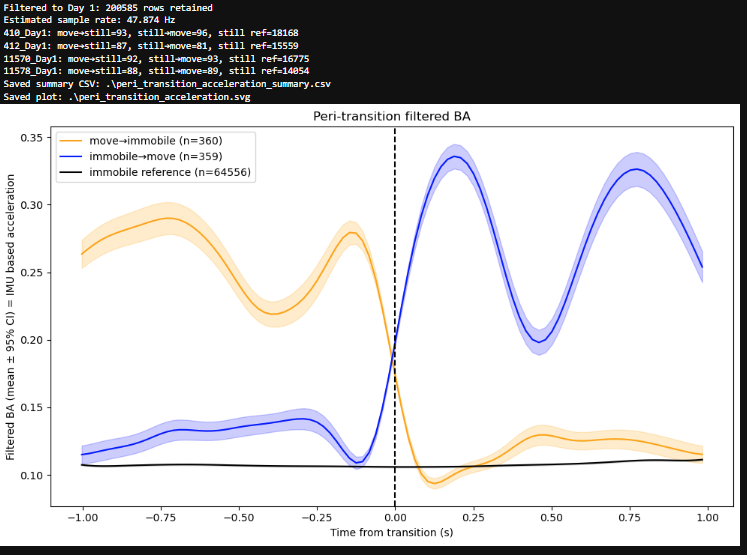

note for plots with Calcium signal, increase window to 2 sec. 

- The file **peri_transition_acceleration_summary.csv** contains the time-aligned, group-level summary of filtered_BA centered on movement transitions. Each row represents a single time point spanning −1 s to +1 s around the transition (t = 0). For each time point, the file reports the mean filtered_BA and corresponding 95% confidence interval for three conditions: move→immobile transitions, immobile→move transitions, and immobile reference windows (stable still periods). The values are averaged across all valid windows pooled across animals (Day 1 only).